In [24]:
import matplotlib as plt 
import pandas as pd  
import yfinance as yf 
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt

In [51]:
# Download historical stock price data from Yahoo Finance
data = yf.download("IBM", start="2020-01-01", end="2025-10-12")['Close']

[*********************100%***********************]  1 of 1 completed


In [52]:
data

Ticker,IBM
Date,
2020-01-02,98.720161
2020-01-03,97.932869
2020-01-06,97.757919
2020-01-07,97.823509
2020-01-08,98.639977
...,...
2025-10-06,284.110199
2025-10-07,288.478516
2025-10-08,284.149445


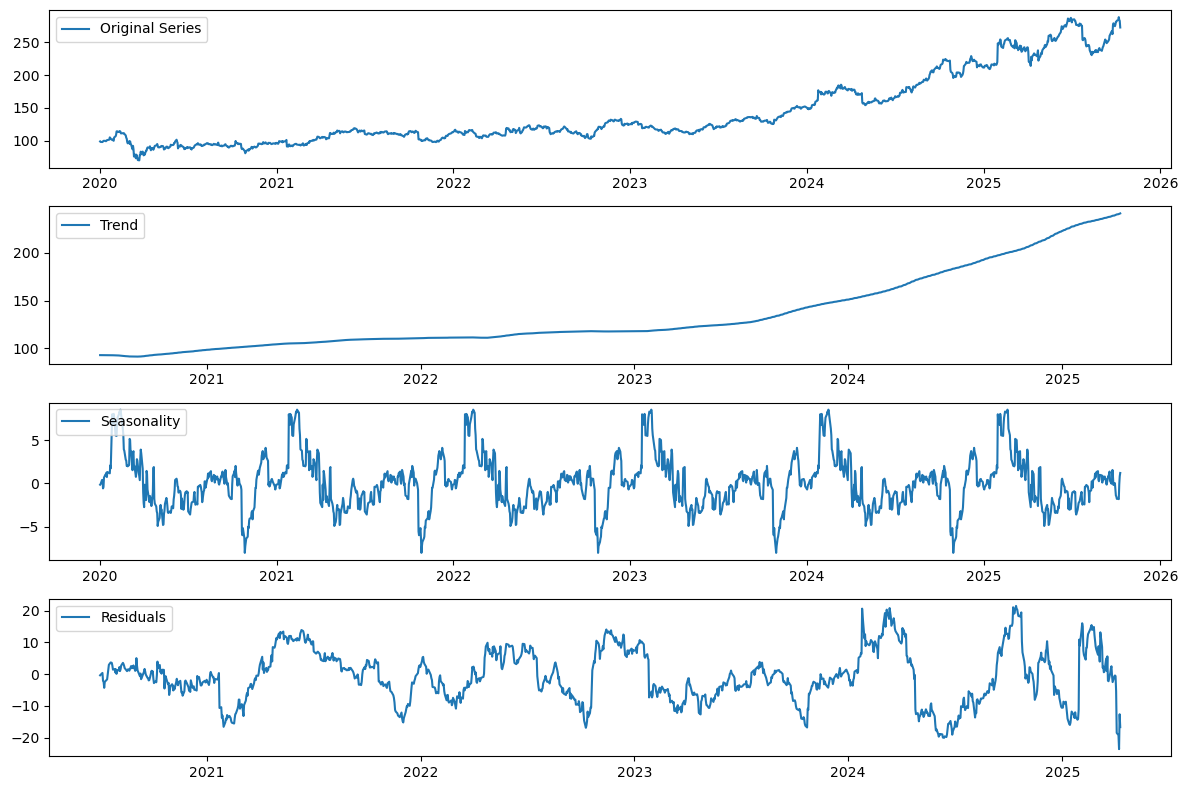

In [53]:
# Decompose the time series into its components
result = seasonal_decompose(data, model='additive', period=252)  # 252 trading days per year

# Visualize decomposition components
plt.figure(figsize=(12, 8))

plt.subplot(411)
plt.plot(data, label='Original Series')
plt.legend(loc='upper left')

plt.subplot(412)
plt.plot(result.trend, label='Trend')
plt.legend(loc='upper left')

plt.subplot(413)
plt.plot(result.seasonal, label='Seasonality')
plt.legend(loc='upper left')

plt.subplot(414)
plt.plot(result.resid, label='Residuals')
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

In [54]:
# Perform Augmented Dickey-Fuller (ADF) test for stationarity
result_adf = adfuller(data)

print(f'ADF Statistic: {result_adf[0]}')
print(f'p-value: {result_adf[1]}')
print('Critical Values:')

ADF Statistic: 0.6014076229744307
p-value: 0.9876502733093628
Critical Values:


In [55]:
if result_adf[1] <= 0.05:
    print("The time series is stationary.")
else:
    print("The time series is not stationary. Consider transforming the data (e.g., differencing) before building a model.")

The time series is not stationary. Consider transforming the data (e.g., differencing) before building a model.


In [56]:
from pmdarima.arima.utils import ndiffs

d = ndiffs(data, test='adf')
print(f"Required differencing order according to the ADF test: d = {d}")

Required differencing order according to the ADF test: d = 1


[*********************100%***********************]  1 of 1 completed


ACF Values (after differencing):
[ 1.         -0.01621257  0.01808476  0.01976787 -0.04105487  0.03182512
 -0.01120341 -0.01282061  0.07990089  0.02666952  0.05160362  0.05933559
  0.00275384  0.04835852 -0.0471931  -0.00347667 -0.02557768 -0.01721418
 -0.00870408 -0.01431637 -0.0348866  -0.05661062 -0.03985698  0.08263386
 -0.05825433  0.03329248 -0.0498195 ]


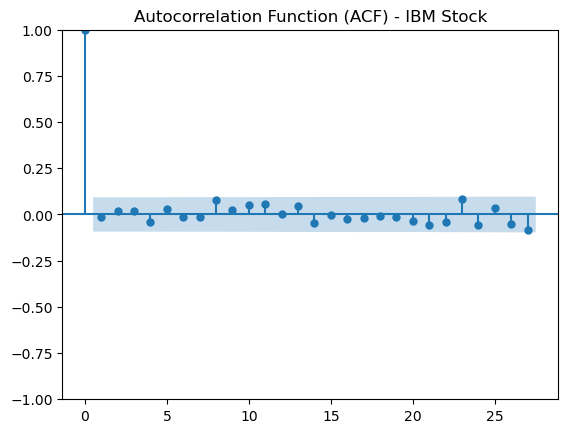

In [59]:
import pandas as pd
import yfinance as yf
from statsmodels.tsa.stattools import acf
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

# Download historical stock data from Yahoo Finance
data = yf.download("IBM", start="2024-01-01", end="2025-10-12")

# Apply first-order differencing to achieve stationarity
data_diff = data['Close'].diff().dropna()

# Compute ACF values on the differenced series
acf_values = acf(data_diff)

# Display ACF values
print("ACF Values (after differencing):")
print(acf_values)

# Plot the Autocorrelation Function (ACF)
plot_acf(data_diff)
plt.title("Autocorrelation Function (ACF) - IBM Stock")
plt.show()

[*********************100%***********************]  1 of 1 completed


PACF Values (after differencing):
[ 1.00000000e+00 -1.55516442e-02  2.68831038e-02  1.29045450e-02
 -3.69444320e-02  4.06805805e-02 -1.91997475e-02  3.20394885e-02
  2.75604595e-02  4.18641113e-02  2.89045352e-02  4.09202785e-02
 -8.23873878e-03  2.90316255e-02 -2.01775445e-02 -2.56245796e-02
 -8.83325020e-03 -1.58167025e-02 -2.00006130e-02 -1.69280918e-02
 -4.12020005e-02 -3.48619893e-02 -5.20444214e-02  6.83574298e-02
 -5.54355153e-02  5.91611192e-03 -3.26145481e-02 -2.66933314e-02
 -1.42172905e-04 -3.09046450e-02 -3.02006360e-02 -1.68442038e-03]


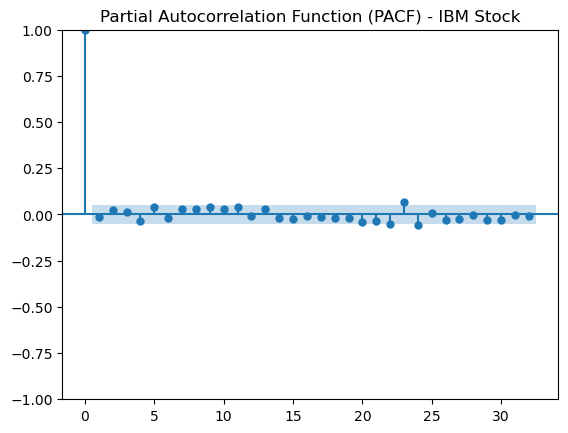

In [60]:
import pandas as pd
import yfinance as yf
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

# Download historical stock data from Yahoo Finance
data = yf.download("IBM", start="2020-01-01", end="2025-10-12")

# Apply first-order differencing to achieve stationarity
data_diff = data['Close'].diff().dropna()

# Compute PACF values on the differenced series
pacf_values = pacf(data_diff)

# Display PACF values
print("PACF Values (after differencing):")
print(pacf_values)

# Plot the Partial Autocorrelation Function (PACF)
plot_pacf(data_diff)
plt.title("Partial Autocorrelation Function (PACF) - IBM Stock")
plt.show()